In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os .path
from sklearn.model_selection import KFold
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model 
from tensorflow.keras.layers import Dropout,Flatten, LeakyReLU, Dense, Input 
import tensorflow as tf

**Extracting Data from Datasets (Divided in 3 folders due to uploding limit on Kaggle**

In [22]:
#Dataset-1

os.chdir("/kaggle/input/rsna-final-36-v14/")
path="/kaggle/input/rsna-final-36-v14/train4/train4/";
classes=os.listdir(path)
#--------------------------------------
#Dataset-2

path2="/kaggle/input/rsna-final-36-v14/Patients_New36/Patients_New36/";
classes2=os.listdir(path2)
#--------------------------------------
#Dataset-3

path3="/kaggle/input/rsna-final-36-v14/train4_version3/train4_version3/";
classes3=os.listdir(path3)

In [23]:
x=[]
y=[]

In [24]:
fol_list_1 = ['00003', '00009', '00007', '00008', '00017', '00018', '00019', '00021',
              '00030', '00032', '00036', '00044', '00045', '00049', '00053', '00061',
              '00064', '00072', '00081', '00088']
for fol in classes:
        seq=os.listdir(path+u'/'+fol)
        for img in seq:
            if(img=='T2w'):
                imgg=img
                im=os.listdir(path+u'/'+fol+u'/'+img)
                for mri in im:
                    pat=path+u'/'+fol+u'/'+img+u'/'+mri
                    fimg=mpimg.imread(pat);
                    x.append(fimg)
                    if fol in fol_list_1:
                        y.append(0)
                    else:
                        y.append(1)

In [25]:
fol_list_2 = ['00090', '00095', '00097', '00099', '00102', '00104', '00108', '00110',
              '00111', '00112', '00113', '00116', '00121', '00122', '00124', '00130',
              '00132', '00133']
for fol in classes2:
        seq=os.listdir(path2+u'/'+fol)
        for img in seq:
            if(img=='T2w'):
                imgg=img
                im=os.listdir(path2+u'/'+fol+u'/'+img)
                for mri in im:
                    pat=path2+u'/'+fol+u'/'+img+u'/'+mri
                    fimg=mpimg.imread(pat);
                    x.append(fimg)
                    if fol in fol_list_2:
                        y.append(0)
                    else:
                        y.append(1)

In [26]:
# fol_list_3 = ['00154', '00157', '00158', '00162', '00165', '00167', '00169', '00170',
#             '00172', '00176', '00183', '00184', '00191', '00192', '00193', '00194',
#             '00195', '00201', '00206', '00209', '00218', '00219']
# for fol in classes3:
#         seq=os.listdir(path3+u'/'+fol)
#         for img in seq:
#             if(img=='T1w'):
#                 imgg=img
#                 im=os.listdir(path3+u'/'+fol+u'/'+img)
#                 for mri in im:
#                     pat=path3+u'/'+fol+u'/'+img+u'/'+mri
#                     fimg=mpimg.imread(pat);
#                     x.append(fimg)
#                     if fol in fol_list_3:
#                         y.append(0)
#                     else:
#                         y.append(1)    

In [27]:
x=np.array(x)
y=np.array(y)

In [28]:
x = x.astype('float32') / 255.
x = x.reshape((len(x), np.prod(x.shape[1:])))
print(x.shape)

(6104, 65536)


In [29]:
n=x.shape[0]
randomize=np.arange(n)
np.random.shuffle(randomize)
randomize
x=x[randomize]
y=y[randomize]

In [30]:
inputs = x
targets = y
print(inputs.shape)
print(targets.shape)

(6104, 65536)
(6104,)


In [31]:
def dice_loss(y_true, y_pred):
    smooth = 1.0
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice_coef = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice_coef

# Register the custom loss function
tf.keras.utils.get_custom_objects()['dice_loss'] = dice_loss

In [32]:
from keras.models import load_model
autoencoders = load_model('/kaggle/input/t2w-model-36/model_for_PhaseOne_T2w.h5')
# autoencoders = load_model('/kaggle/input/t1w-model-36/model_for_PhaseOne_T1w.h5')
# autoencoders = load_model('/kaggle/input/t1wce-model-36/model_for_PhaseOne_T1wCE.h5')
# autoencoders = load_model('/kaggle/input/flair-model-36/model_for_PhaseOne_FLAIR.h5')
# autoencoders = load_model('/kaggle/input/d1-model-combined/model_for_PhaseOne_D1.h5')

In [33]:
from keras import backend as K
def SparseRegularizer(activation_matrix):
    
    p = 0.2
    beta1 = 0.05
    beta2 = 5.00
    glob=1056 # based on the code layer of the autoencdoer
    
    p_hat = K.mean(activation_matrix)
    local=K.std(activation_matrix)
    KL_divergence = p*(K.log(p/p_hat)) + (1-p)*(K.log(1-p/1-p_hat))
    sum = K.sum(KL_divergence)
    result = tf.cond(local<glob, lambda: beta1*sum, lambda: beta2*sum  )
    return result

In [34]:
model2=Sequential()
model2.trainable=False
for layer in autoencoders.layers:
    layer.trainable=False
hidden = Flatten()(autoencoders.layers[-7].output,)
# hidden= Dense(64, activation='sigmoid', use_bias=True,name='hidden_layer')(hidden) #Sparse Regularizer

hidden= Dense(64, activation='sigmoid', use_bias=True,activity_regularizer=SparseRegularizer,name='hidden_layer')(hidden) #Sparse Regularizer
outputs2 = Dense(1, activation='sigmoid', use_bias=True, name='output_layer')(hidden)
model = Model(inputs=autoencoders.input, outputs=outputs2)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 65536)]           0         
                                                                 
 dense_11 (Dense)            (None, 512)               33554944  
                                                                 
 dense_12 (Dense)            (None, 256)               131328    
                                                                 
 dense_13 (Dense)            (None, 128)               32896     
                                                                 
 dense_14 (Dense)            (None, 64)                8256      
                                                                 
 dense_15 (Dense)            (None, 32)                2080      
                                                                 
 flatten_1 (Flatten)         (None, 32)                0   

In [35]:
# import pynvml
# pynvml.nvmlInit()
# deviceCount = pynvml.nvmlDeviceGetCount()
# for i in range(deviceCount):
#     handle = pynvml.nvmlDeviceGetHandleByIndex(i)
#     print(f"Device {i} {pynvml.nvmlDeviceGetName(handle)}")


In [36]:
# import matplotlib.pylab as plt
# from scipy import interp
# from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
# from sklearn.model_selection import StratifiedKFold
# import matplotlib.patches as patches
# import numpy as np
# import pandas as pd
# import warnings

# warnings.filterwarnings("ignore", category=DeprecationWarning, message="scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead")


# seed = 7
# np.random.seed(seed)
# tprs_train = []  # Store train set TPR for each fold
# tprs_test = []   # Store test set TPR for each fold
# mean_fpr = np.linspace(0, 1, 100)
# fold_no = 1
# aucs_train = []  # Store train set AUC for each fold
# aucs_test = []   # Store test set AUC for each fold
# precision_scores = []
# recall_scores = []
# f1_scores = []
# accuracy_scores = []
# sensitivity_scores = []     # Add sensitivity scores list
# specificity_scores = []     # Add specificity scores list

# # fig, ax = plt.subplots()
# kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

# # for i, (train, test) in enumerate(cv.split(X_13 , target)):
# X_train = inputs
# y_train = targets
# for train, test in kfold.split(X_train, y_train):
#     print(f"Training on fold {fold_no}...")
#     model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
#     model.fit(X_train[train], y_train[train], epochs=20, batch_size=1, verbose=0)
#     scores_train = model.predict_on_batch(X_train[train]).ravel()
#     scores_test = model.predict_on_batch(X_train[test]).ravel()

#     # Evaluate the model for train and test sets
#     y_pred_train = scores_train.round()
#     y_pred_test = scores_test.round()

#     fpr_train, tpr_train, thresholds_train = roc_curve(y_train[train], scores_train)
#     fpr_test, tpr_test, thresholds_test = roc_curve(y_train[test], scores_test)

#     # Calculate AUC for train and test sets
#     roc_auc_train = auc(fpr_train, tpr_train)
#     roc_auc_test = auc(fpr_test, tpr_test)

#     aucs_train.append(roc_auc_train)
#     aucs_test.append(roc_auc_test)

#     # Calculate other metrics for train and test sets
#     precision_scores.append(precision_score(y_train[test], y_pred_test))
#     recall_scores.append(recall_score(y_train[test], y_pred_test))
#     f1_scores.append(f1_score(y_train[test], y_pred_test))
#     accuracy_scores.append(accuracy_score(y_train[test], y_pred_test))

#     # Calculate TP, FP, TN, FN for sensitivity and specificity
#     TP = np.sum((y_train[test] == 1) & (y_pred_test == 1))
#     FP = np.sum((y_train[test] == 0) & (y_pred_test == 1))
#     TN = np.sum((y_train[test] == 0) & (y_pred_test == 0))
#     FN = np.sum((y_train[test] == 1) & (y_pred_test == 0))

#     sensitivity = TP / (TP + FN)
#     specificity = TN / (TN + FP)
#     sensitivity_scores.append(sensitivity)
#     specificity_scores.append(specificity)

#     # Store the train and test TPRs for each fold
#     tprs_train.append(interp(mean_fpr, fpr_train, tpr_train))
#     tprs_test.append(interp(mean_fpr, fpr_test, tpr_test))

#     fold_no += 1


# print("F1 Score: ", np.mean(f1_scores))
# print("Accuracy: ", np.mean(accuracy_scores))
# print("Sensitivity: ", np.mean(sensitivity_scores))
# print("Specificity: ", np.mean(specificity_scores))
# print("Precision: ", np.mean(precision_scores))
# print("Recall: ", np.mean(recall_scores))
import matplotlib.pylab as plt
from scipy import interp
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import warnings
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras.models import load_model

warnings.filterwarnings("ignore", category=DeprecationWarning, message="scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead")
cumulative_TP = 0
cumulative_FP = 0
cumulative_TN = 0
cumulative_FN = 0
seed = 7
np.random.seed(seed)
tprs_train = []  # Store train set TPR for each fold
tprs_test = []   # Store test set TPR for each fold
mean_fpr = np.linspace(0, 1, 100)
fold_no = 1
aucs_train = []  # Store train set AUC for each fold
aucs_test = []   # Store test set AUC for each fold
precision_scores = []
recall_scores = []
f1_scores = []
accuracy_scores = []
sensitivity_scores = []     # Add sensitivity scores list
specificity_scores = []     # Add specificity scores list

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

X_train = inputs
y_train = targets
for train, test in kfold.split(X_train, y_train):
    print(f"Training on fold {fold_no}...")
    model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
    model.fit(X_train[train], y_train[train], epochs=20, batch_size=1, verbose=0)

    # Save the model
    model.save(f'/kaggle/working/model_fold_{fold_no}.h5')

    scores_train = model.predict_on_batch(X_train[train]).ravel()
    scores_test = model.predict_on_batch(X_train[test]).ravel()

    # Evaluate the model for train and test sets
    y_pred_train = scores_train.round()
    y_pred_test = scores_test.round()

    fpr_train, tpr_train, thresholds_train = roc_curve(y_train[train], scores_train)
    fpr_test, tpr_test, thresholds_test = roc_curve(y_train[test], scores_test)

    roc_auc_train = auc(fpr_train, tpr_train)
    roc_auc_test = auc(fpr_test, tpr_test)

    aucs_train.append(roc_auc_train)
    aucs_test.append(roc_auc_test)
    precision_scores.append(precision_score(y_train[test], y_pred_test))
    recall_scores.append(recall_score(y_train[test], y_pred_test))
    f1_scores.append(f1_score(y_train[test], y_pred_test))
    accuracy_scores.append(accuracy_score(y_train[test], y_pred_test))
    print(accuracy_scores)
    TP = np.sum((y_train[test] == 1) & (y_pred_test == 1))
    FP = np.sum((y_train[test] == 0) & (y_pred_test == 1))
    TN = np.sum((y_train[test] == 0) & (y_pred_test == 0))
    FN = np.sum((y_train[test] == 1) & (y_pred_test == 0))

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    sensitivity_scores.append(sensitivity)
    specificity_scores.append(specificity)

    tprs_train.append(interp(mean_fpr, fpr_train, tpr_train))
    tprs_test.append(interp(mean_fpr, fpr_test, tpr_test))
    predictions = model.predict(inputs[test]) > 0.5
    
    # Update the cumulative variables for the confusion matrix
    cm = confusion_matrix(targets[test], predictions)
    cumulative_TP += cm[1, 1]
    cumulative_FP += cm[0, 1]
    cumulative_TN += cm[0, 0]
    cumulative_FN += cm[1, 0]

    fold_no += 1

print("F1 Score: ", np.mean(f1_scores))
print("Accuracy: ", np.mean(accuracy_scores))
print("Sensitivity: ", np.mean(sensitivity_scores))
print("Specificity: ", np.mean(specificity_scores))
print("Precision: ", np.mean(precision_scores))
print("Recall: ", np.mean(recall_scores))


Training on fold 1...
[0.8828828828828829]
39/39 [==============================] - 0s 6ms/step
Training on fold 2...
[0.8828828828828829, 0.9009009009009009]
39/39 [==============================] - 0s 6ms/step
Training on fold 3...
[0.8828828828828829, 0.9009009009009009, 0.9246519246519247]
39/39 [==============================] - 0s 5ms/step
Training on fold 4...
[0.8828828828828829, 0.9009009009009009, 0.9246519246519247, 0.9426699426699426]
39/39 [==============================] - 0s 6ms/step
Training on fold 5...
[0.8828828828828829, 0.9009009009009009, 0.9246519246519247, 0.9426699426699426, 0.9377049180327869]
39/39 [==============================] - 0s 6ms/step
F1 Score:  0.9081863665453387
Accuracy:  0.9177621138276877
Sensitivity:  0.9146123601169472
Specificity:  0.920317335086566
Precision:  0.9032560055781556
Recall:  0.9146123601169472


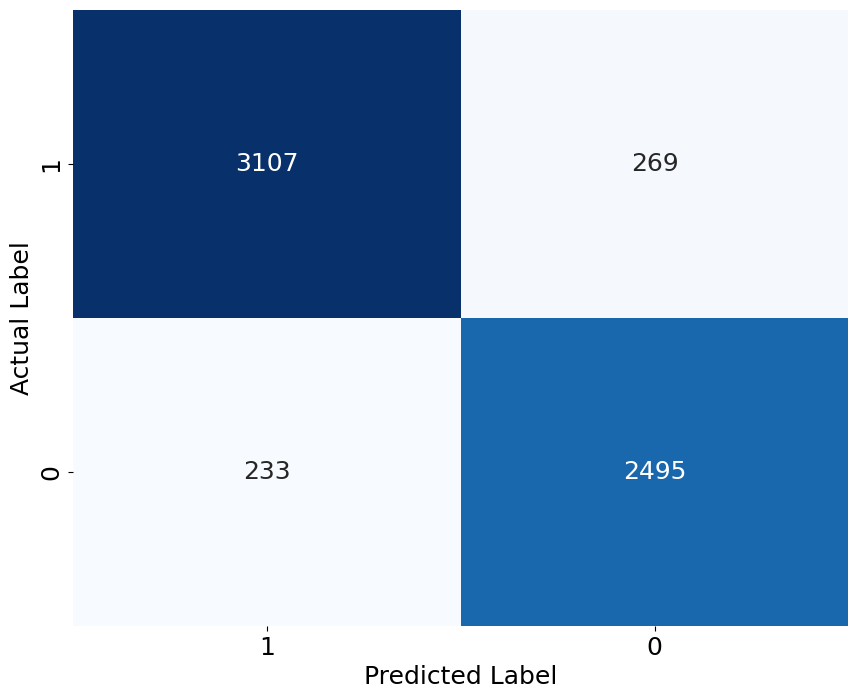

In [38]:
overall_confusion_matrix = np.array([[cumulative_TN, cumulative_FP],
                                     [cumulative_FN, cumulative_TP]])

# Plotting the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overall_confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1', '0'], yticklabels=['1', '0'],annot_kws={"size": 18}, cbar=False)
plt.ylabel('Actual Label', fontsize=18)
plt.xlabel('Predicted Label',fontsize=18)
ax.tick_params(axis='x', labelsize=18)  # Set xticks size
ax.tick_params(axis='y', labelsize=18)  # Set yticks size
# plt.title('Aggregated Confusion Matrix over all Folds')
plt.savefig('/kaggle/working/confusion_matrix_T2w.png')  # Save the figure
plt.show()

In [42]:
model = load_model('/kaggle/working/model_fold_4.h5', custom_objects={'SparseRegularizer': SparseRegularizer})

# ROC for Phase-2

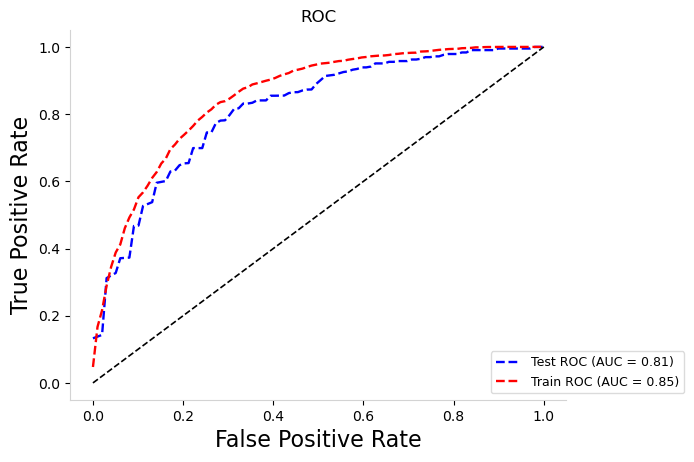

In [111]:
# Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mean_tpr_train = np.mean(tprs_train, axis=0)
mean_auc_train = auc(mean_fpr, mean_tpr_train)

mean_tpr_test = np.mean(tprs_test, axis=0)
mean_auc_test = auc(mean_fpr, mean_tpr_test)

fig, ax = plt.subplots()

# Plot the test ROC curve with label and customizations
ax.plot(mean_fpr, mean_tpr_test,  lw=1.7, linestyle='--', label='Test ROC (AUC = %0.2f)' % (mean_auc_test), color='blue', zorder=2)
# Plot the train ROC curve with label and customizations
ax.plot(mean_fpr, mean_tpr_train,  lw=1.7, linestyle='--', label='Train ROC (AUC = %0.2f)'% (mean_auc_train), color='red', zorder=2)

# Plot the diagonal line (random classifier) with customizations
ax.plot([0, 1], [0, 1], linestyle='--', lw=1.2, color='black', zorder=2)

# Set axis labels and title
ax.set_title('ROC')
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)


# Remove the top and right spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the linewidth and color of the remaining spines (bottom and left)
frame_color = 'lightgrey'
frame_linewidth = 0.8
ax.spines['bottom'].set_linewidth(frame_linewidth)
ax.spines['bottom'].set_color(frame_color)
ax.spines['left'].set_linewidth(frame_linewidth)
ax.spines['left'].set_color(frame_color)

# Make the legend transparent and position it outside the plot
legend = ax.legend(prop={'size': 9}, loc='lower right', bbox_to_anchor=(1.25, 0))
legend.get_frame().set_alpha(0.7)

# Save the plot as a PDF file and display it
plt.savefig('/kaggle/working/Phase_II_MPmri.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()


# Model Prediction on 100 Images 50/0 and 50/1

In [124]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image
from tensorflow.keras.preprocessing import image


# Path to validation images
os.chdir("/kaggle/input/rsna-final-36-v14/")
path="/kaggle/input/rsna-final-36-v14/ValidationData-All-4/ValidationData-T1w";
classes=os.listdir(path)
print(classes)

images = []
labels = []

for class_folder in classes:
    class_path = os.path.join(path, class_folder)

    for img_filename in os.listdir(class_path):
        img_path = os.path.join(class_path, img_filename)
        img = mpimg.imread(img_path)
#         print(img_path)
        images.append(img)
        labels.append(int(class_folder))
#         print(labels)
    
        
X = np.array(images)
n=X.shape[0]
randomize=np.arange(n)
np.random.shuffle(randomize)
randomize
X=X[randomize]
y=y[randomize]
y = np.array(labels)
X= X.astype('float32') / 255.
X= X.reshape((len(X), np.prod(X.shape[1:])))
print(X.shape)

print(y)

predictions = model.predict(X)
predicted_labels = (predictions > 0.5).astype(int)
print(list(predicted_labels))
# Evaluate results
accuracy = np.mean(predicted_labels == y)
print(f"Accuracy: {accuracy:.2f}")

['0', '1']
(42, 65536)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1]
2/2 [==============================] - 0s 4ms/step
[array([1]), array([1]), array([1]), array([0]), array([0]), array([1]), array([1]), array([1]), array([1]), array([1]), array([1]), array([1]), array([1]), array([0]), array([1]), array([1]), array([1]), array([1]), array([0]), array([1]), array([1]), array([0]), array([1]), array([1]), array([1]), array([0]), array([1]), array([0]), array([1]), array([1]), array([1]), array([1]), array([1]), array([1]), array([0]), array([0]), array([1]), array([1]), array([0]), array([1]), array([0]), array([1])]
Accuracy: 0.50


In [125]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y,predicted_labels)

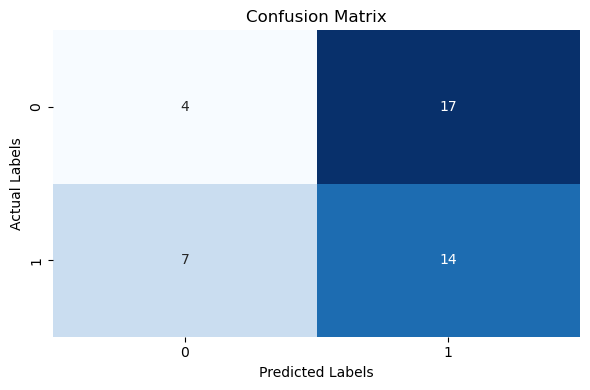

In [126]:
from sklearn.metrics import confusion_matrix, plot_confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")
plt.tight_layout()  # Make sure the plot layout is tight

# Save confusion matrix plot as an image (PDF format)
plt.savefig('/kaggle/working/confusion_matrix_T1w_2.pdf', format='pdf')
plt.show()

In [66]:
from IPython.display import FileLink
FileLink(r'model_fold_9.h5')

/kaggle/input/rsna-final-36-v14/model_fold_9.h5

# Comparison with Thi's Paper Result ROC

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
data = pd.read_csv('/kaggle/input/this-method/Thi Plot Dataset3 (1).csv')
data.columns

Index(['X', 'Y'], dtype='object')

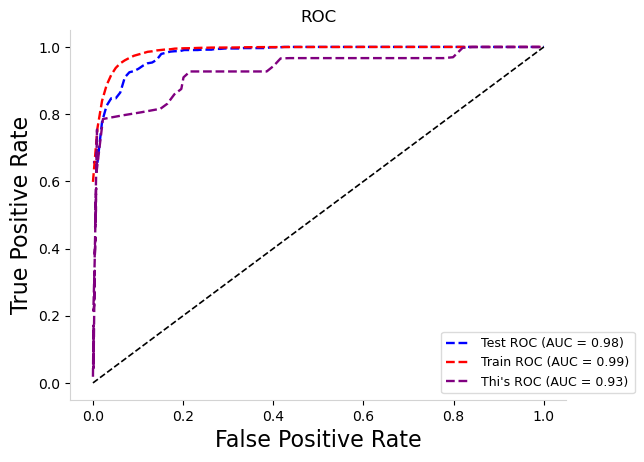

In [21]:
fig, ax = plt.subplots()

# Plot the test ROC curve with label and customizations
ax.plot(mean_fpr, mean_tpr_test,  lw=1.7, linestyle='--', label='Test ROC (AUC = %0.2f)' % (mean_auc_test), color='blue', zorder=2)
# Plot the train ROC curve with label and customizations
ax.plot(mean_fpr, mean_tpr_train,  lw=1.7, linestyle='--', label='Train ROC (AUC = %0.2f)'% (mean_auc_train), color='red', zorder=2)

ax.plot(data['X'], data['Y'],  lw=1.7, linestyle='--', label="Thi's ROC (AUC = %0.2f)" % 0.93, color='purple', zorder=2)

# Plot the diagonal line (random classifier) with customizations
ax.plot([0, 1], [0, 1], linestyle='--', lw=1.2, color='black', zorder=2)

# Set axis labels and title
ax.set_title('ROC')
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)


# Remove the top and right spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the linewidth and color of the remaining spines (bottom and left)
frame_color = 'lightgrey'
frame_linewidth = 0.8
ax.spines['bottom'].set_linewidth(frame_linewidth)
ax.spines['bottom'].set_color(frame_color)
ax.spines['left'].set_linewidth(frame_linewidth)
ax.spines['left'].set_color(frame_color)

# Make the legend transparent and position it outside the plot
legend = ax.legend(prop={'size': 9}, loc='lower right', bbox_to_anchor=(1.15, 0))
legend.get_frame().set_alpha(0.7)

# Save the plot as a PDF file and display it
plt.savefig('/kaggle/working/Phase_II_MPMRI_2.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()